# Time Domain vs Frequency Domain

Exploring how a signal can be represented in the time and frequency domains using the Fourier Transform and FFT.

## Objective

In this notebook, we will explore the relationship between the time and frequency domains.

We will:

- Generate sinusoidal signals
- Combine multiple frequencies
- Observe the signal in the time domain
- Analyze its frequency content using the FFT
- Investigate how changing frequency components affects the spectrum

## Theory

A signal can be represented in different domains.

### Time Domain

The time-domain representation shows how a signal changes over time.

### Frequency Domain

The frequency-domain representation shows which frequency components are present in the signal and their relative magnitudes.

The Fourier Transform provides the mathematical relationship between these two representations.

For a discrete signal, the Fast Fourier Transform (FFT) is an efficient algorithm for computing the Discrete Fourier Transform (DFT).

For a sinusoidal signal:

$$
x(t) = A\sin(2\pi f t + \phi)
$$

the frequency-domain representation contains a component at its frequency $f$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
fs = 1000
duration = 1.0

t = np.arange(0, duration, 1/fs)

print(f"Sampling frequency: {fs} Hz")
print(f"Number of samples: {len(t)}")

Sampling frequency: 1000 Hz
Number of samples: 1000


In [3]:
A = 1
f = 10
phi = 0

x = A * np.sin(2 * np.pi * f * t + phi)

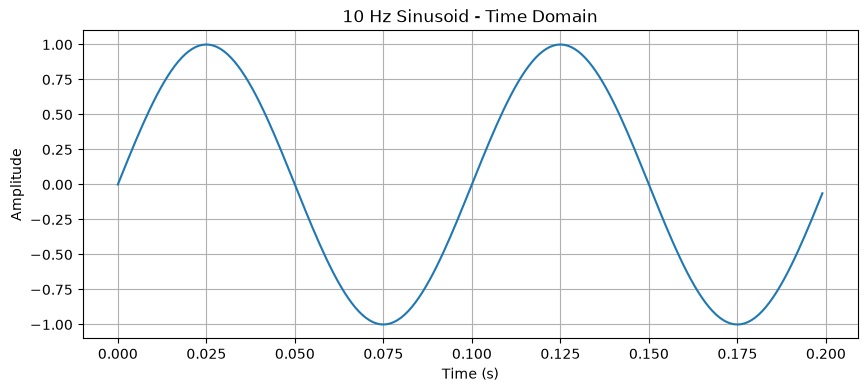

In [4]:
plt.figure(figsize=(10, 4))

plt.plot(t[:200], x[:200])

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("10 Hz Sinusoid - Time Domain")
plt.grid(True)

plt.show()

In [5]:
X = np.fft.fft(x)
freqs = np.fft.fftfreq(len(x), 1/fs)

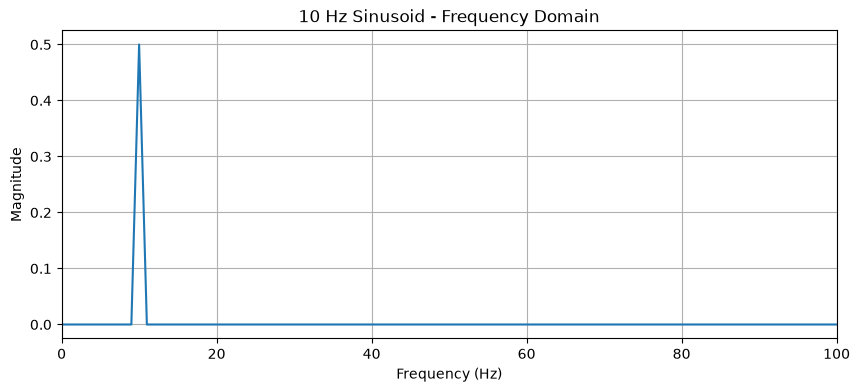

In [6]:
positive = freqs >= 0

plt.figure(figsize=(10, 4))

plt.plot(freqs[positive], np.abs(X[positive]) / len(x))

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("10 Hz Sinusoid - Frequency Domain")
plt.xlim(0, 100)
plt.grid(True)

plt.show()

## Observations

- In time domain we see a 10Hz sinusoid wave, having 0.1s period, oscillating with 1 amplitude.
- Analyzing in frequency domain, a spike on 10Hz at x-axis, having 0.5 magnitude at y-axis, is observed.
- The observation is correct since the wave have 10Hz frequency.
- The magnitude is 0.5 because the amplitude of a real sinusoid is split equally between its positive and negative frequency components.

In [7]:
A1 = 1
A2 = 0.5
A3 = 0.25

f1 = 10
f2 = 50
f3 = 120

x = (
    A1 * np.sin(2 * np.pi * f1 * t) +
    A2 * np.sin(2 * np.pi * f2 * t) +
    A3 * np.sin(2 * np.pi * f3 * t)
)

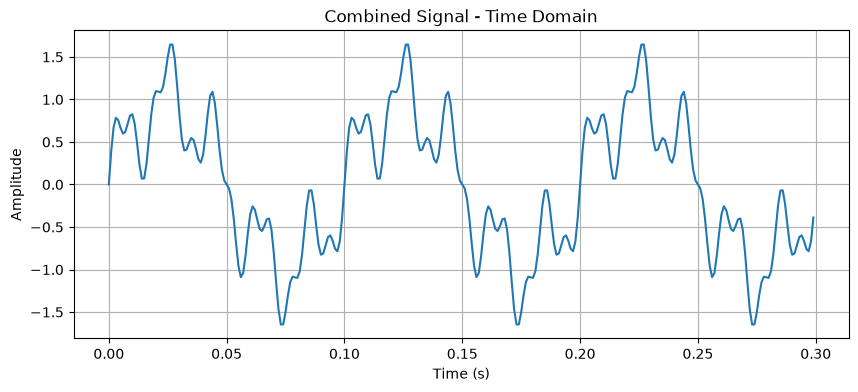

In [8]:
plt.figure(figsize=(10, 4))

plt.plot(t[:300], x[:300])

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Combined Signal - Time Domain")
plt.grid(True)

plt.show()

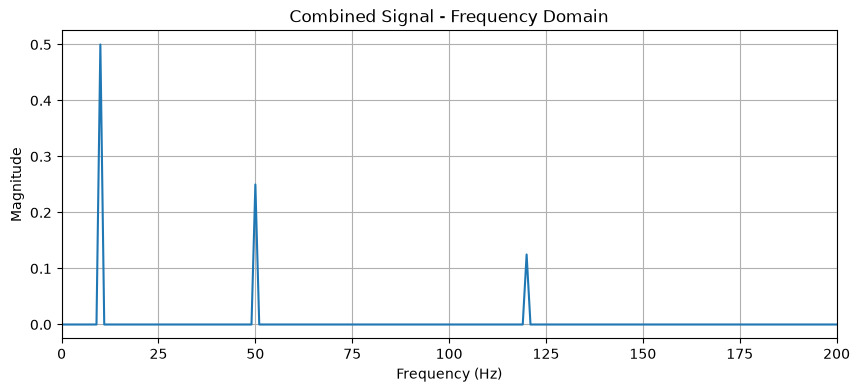

In [9]:
X = np.fft.fft(x)

plt.figure(figsize=(10, 4))

plt.plot(freqs[positive], np.abs(X[positive]) / len(x))

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Combined Signal - Frequency Domain")
plt.xlim(0, 200)
plt.grid(True)

plt.show()

## Observations

- Three different frequency spikes are observed in frequency domain.
- The spikes are located at 10Hz, 50Hz and 120Hz.
- Magnitudes are different due to respective amplitudes being different.
- Frequency domain makes it easier to observe different frquencies compared to time domain.

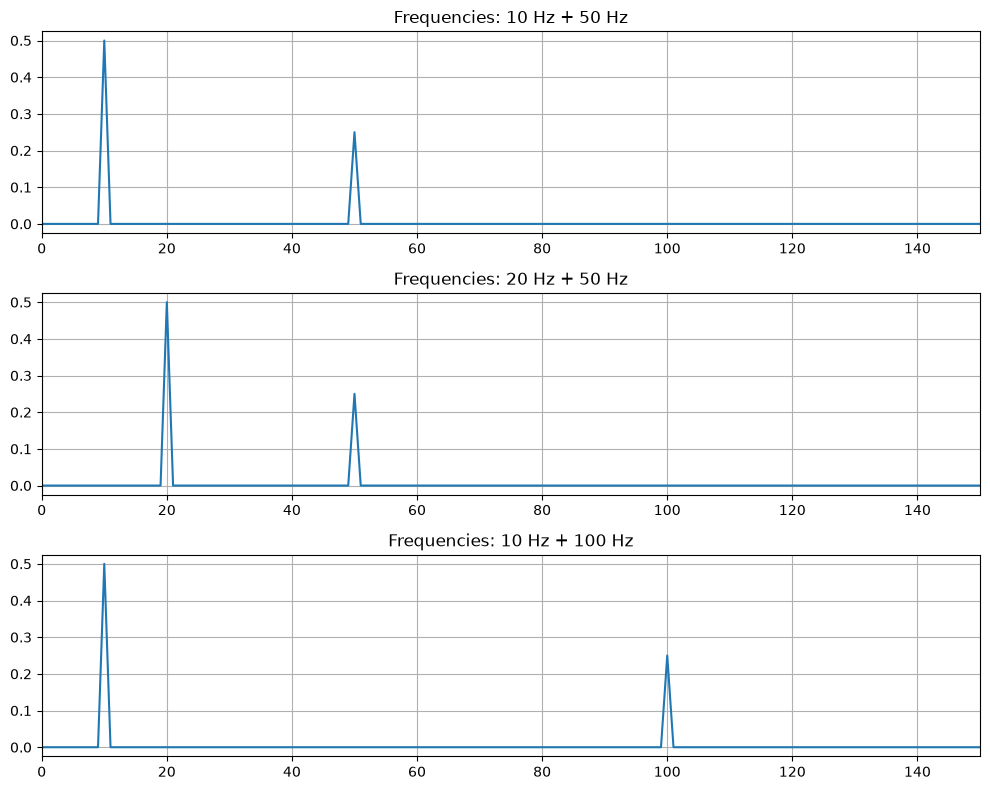

In [10]:
signals = [
    (10, 50),
    (20, 50),
    (10, 100),
]

plt.figure(figsize=(10, 8))

for i, (f1, f2) in enumerate(signals, 1):
    x_test = (
        np.sin(2 * np.pi * f1 * t) +
        0.5 * np.sin(2 * np.pi * f2 * t)
    )

    X_test = np.fft.fft(x_test)

    plt.subplot(3, 1, i)
    plt.plot(freqs[positive],
             np.abs(X_test[positive]) / len(x_test))
    plt.xlim(0, 150)
    plt.grid(True)
    plt.title(f"Frequencies: {f1} Hz + {f2} Hz")

plt.tight_layout()
plt.show()

## Observations

- Spikes on frequency domain change as different frquencies are applied.

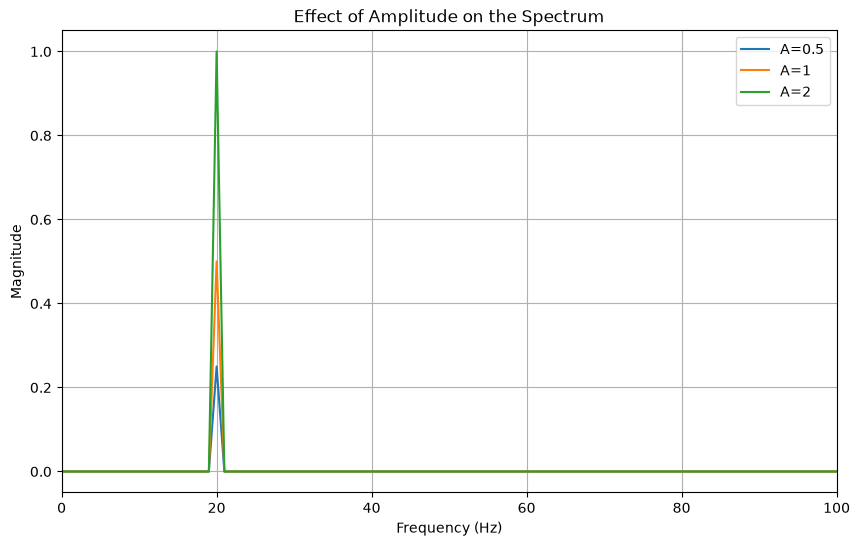

In [11]:
A_values = [0.5, 1, 2]

plt.figure(figsize=(10, 6))

for A in A_values:
    x_test = A * np.sin(2 * np.pi * 20 * t)
    X_test = np.fft.fft(x_test)

    plt.plot(
        freqs[positive],
        np.abs(X_test[positive]) / len(x_test),
        label=f"A={A}"
    )

plt.xlim(0, 100)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Effect of Amplitude on the Spectrum")
plt.legend()
plt.grid(True)

plt.show()

## Observations

- Three different waves having the same frequency and different amplitudes overlap each other.

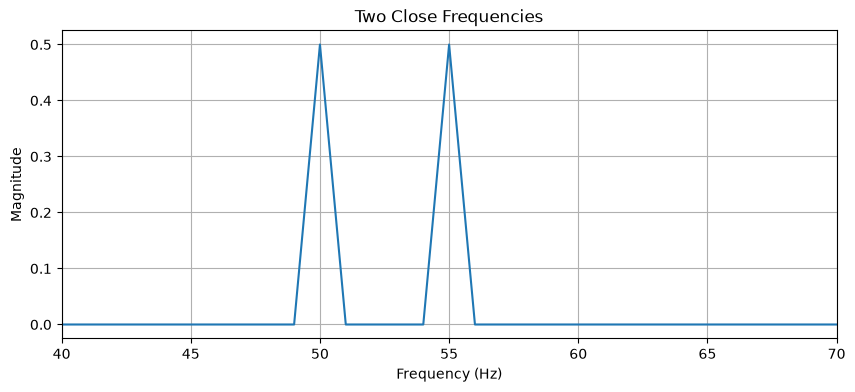

In [12]:
fs = 1000
duration = 1.0

t = np.arange(0, duration, 1/fs)

f1 = 50
f2 = 55

x = (
    np.sin(2 * np.pi * f1 * t) +
    np.sin(2 * np.pi * f2 * t)
)

X = np.fft.fft(x)
freqs = np.fft.fftfreq(len(x), 1/fs)

positive = freqs >= 0

plt.figure(figsize=(10, 4))

plt.plot(
    freqs[positive],
    np.abs(X[positive]) / len(x)
)

plt.xlim(40, 70)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Two Close Frequencies")
plt.grid(True)

plt.show()

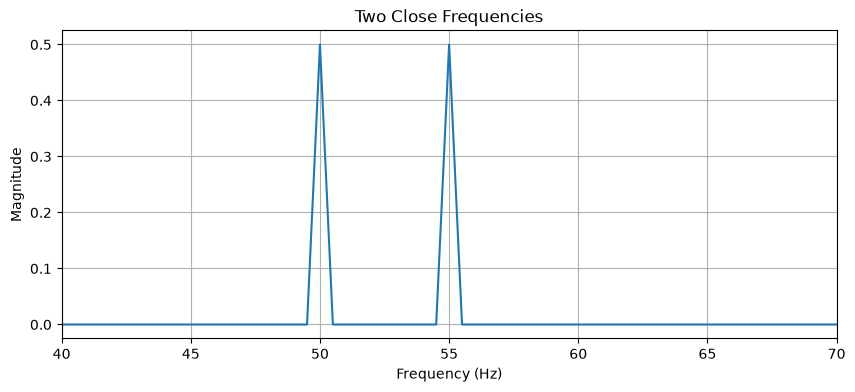

In [14]:
fs = 1000
duration = 2.0

t = np.arange(0, duration, 1/fs)

f1 = 50
f2 = 55

x = (
    np.sin(2 * np.pi * f1 * t) +
    np.sin(2 * np.pi * f2 * t)
)

X = np.fft.fft(x)
freqs = np.fft.fftfreq(len(x), 1/fs)

positive = freqs >= 0

plt.figure(figsize=(10, 4))

plt.plot(
    freqs[positive],
    np.abs(X[positive]) / len(x)
)

plt.xlim(40, 70)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Two Close Frequencies")
plt.grid(True)

plt.show()

## Observation

A longer observation time gives better frequency resolution:

$$
\Delta f = \frac{1}{T}
$$

With 2 s instead of 1 s, the 50 Hz and 55 Hz components are easier to distinguish.